In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import statsmodels.formula.api as smf

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12



In [2]:
folder = r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Decoder'

analysis_='\overrepresentation_EGO_vs_ALLO' 

df=pd.DataFrame()

for phase in ['\Phase1', '\Phase2']:
    folder_ = folder + phase + analysis_
    file= '\ego_vs_allo_sandwell_overrepresentation.csv'

    df_=pd.read_csv(folder_+file)

    df=pd.concat([df,df_]).reset_index(drop=True)

In [3]:
df

,strategy,phase,subject,session,sandwell_overrepresentation
0,EGO,1,H2222,E28,0.352877
1,EGO,1,H2222,E29,-0.562269
2,EGO,1,H2222,E30,0.326068
3,EGO,1,H2222,E31,-0.010993
4,EGO,1,H2222,E32,0.183442
...,...,...,...,...,...
102,ALLO,2,H2231,A30,0.110693
103,ALLO,2,H2231,A31,0.140783
104,ALLO,2,H2231,A32,0.094486
105,ALLO,2,H2231,A33,0.172834


                  Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sandwell_overrepresentation
No. Observations: 107     Method:             ML                         
No. Groups:       8       Scale:              0.0195                     
Min. group size:  12      Log-Likelihood:     52.7210                    
Max. group size:  14      Converged:          Yes                        
Mean group size:  13.4                                                   
----------------------------------------------------------------------------
                     Coef.    Std.Err.      z      P>|z|    [0.025    0.975]
----------------------------------------------------------------------------
Intercept            0.188       0.032    5.859    0.000     0.125     0.251
strategy[T.EGO]      0.051       0.027    1.900    0.057    -0.002     0.105
Group Var            0.005       0.025                                      



C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


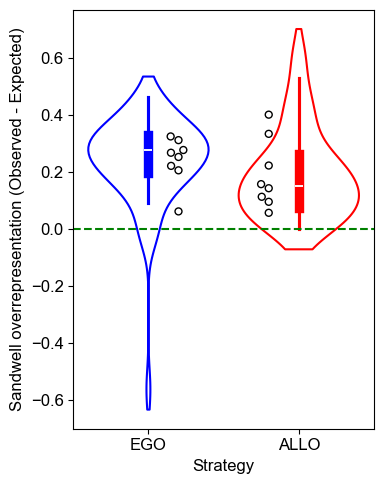

In [4]:

data_grouped=df.groupby(['subject','strategy'])['sandwell_overrepresentation'].mean().reset_index()

palette_egoallo = {
    "ALLO": "red",
    "EGO": "blue"
}

palette_white = {
    "ALLO": "white",
    "EGO": "white"
}

plt.figure(figsize=(4,5))

sns.violinplot(
    data=df,
    x="strategy",
    y="sandwell_overrepresentation",
    inner='boxplot',
    cut=True,
    hue='strategy',
   # dodge=True,
    palette=palette_egoallo,
    fill=False
)

plt.axhline(0, linestyle= '--', color='g')

#-----------------------------


model = smf.mixedlm(
    "sandwell_overrepresentation ~ strategy",
    df,
    groups=df["subject"],
)

result = model.fit(reml=False)
print(result.summary())
#-----------------------------

sns.swarmplot(
    data=data_grouped,
    x="strategy",
    y="sandwell_overrepresentation",
    hue='strategy',
    dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5
)

plt.ylabel('Sandwell overrepresentation (Observed - Expected)')
plt.xlabel('Strategy')

#plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs\Decoder', 
                         "SW overrepresentation.svg"), dpi=300, bbox_inches="tight")

plt.show()


In [21]:
analysis_='\overrepresentation_SAM_vs_CHO' 

df=pd.DataFrame()

for phase in ['\Phase1', '\Phase2']:
    folder_ = folder + phase + analysis_
    file= '\sam_vs_cho_sandwell_overrepresentation.csv'

    df_=pd.read_csv(folder_+file)

    df=pd.concat([df,df_]).reset_index(drop=True)

In [22]:
df

,trial_stage,phase,subject,session,strategy,sandwell_overrepresentation
0,SAM,1,H2226,A28,ALLO,0.022798
1,SAM,1,H2226,A29,ALLO,0.168223
2,SAM,1,H2226,A30,ALLO,0.035131
3,SAM,1,H2226,A31,ALLO,0.025004
4,SAM,1,H2226,A32,ALLO,-0.057410
...,...,...,...,...,...,...
206,CHO,2,H2231,A30,ALLO,0.128477
207,CHO,2,H2231,A31,ALLO,0.171284
208,CHO,2,H2231,A32,ALLO,0.106561
209,CHO,2,H2231,A33,ALLO,0.191132


C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                  Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sandwell_overrepresentation
No. Observations: 211     Method:             ML                         
No. Groups:       8       Scale:              0.0244                     
Min. group size:  22      Log-Likelihood:     84.9895                    
Max. group size:  28      Converged:          Yes                        
Mean group size:  26.4                                                   
---------------------------------------------------------------------------
                       Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
---------------------------------------------------------------------------
Intercept               0.208      0.031    6.739   0.000    0.147    0.268
strategy[T.EGO]         0.042      0.022    1.937   0.053   -0.000    0.084
trial_stage[T.SAM]     -0.016      0.022   -0.761   0.447   -0.059    0.026
Group Var               0.005      0.018    

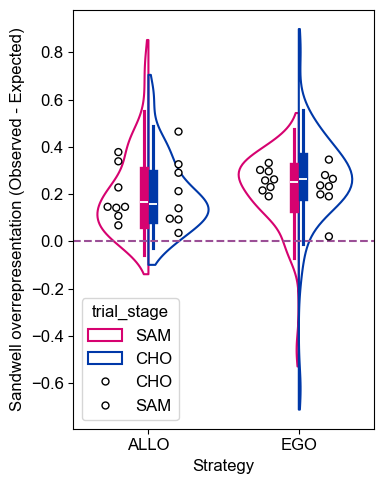

In [23]:

data_grouped=df.groupby(['subject','strategy', 'trial_stage'])['sandwell_overrepresentation'].mean().reset_index()

palette_samcho = {
    "SAM": "#D60270",
    "CHO": "#0038A8"
}

palette_white = {
    "SAM": "white",
    "CHO": "white"
}

plt.figure(figsize=(4,5))

sns.violinplot(
    data=df,
    hue="trial_stage",
    y="sandwell_overrepresentation",
    inner='boxplot',
    cut=True,
    x='strategy',
   # dodge=True,
    palette=palette_samcho,
    fill=False,
    split=True
)

plt.axhline(0, linestyle= '--', color='#9B4F96')

#-----------------------------


model = smf.mixedlm(
    "sandwell_overrepresentation ~ strategy + trial_stage",
    df,
    groups=df["subject"],
)

result = model.fit(reml=False)
print(result.summary())
#-----------------------------

sns.swarmplot(
    data=data_grouped,
    hue="trial_stage",
    y="sandwell_overrepresentation",
    x='strategy',
    dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5
)

plt.ylabel('Sandwell overrepresentation (Observed - Expected)')
plt.xlabel('Strategy')

#plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs\Decoder', 
                         "SW overrepresentation SAM CHO.svg"), dpi=300, bbox_inches="tight")

plt.show()


                  Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sandwell_overrepresentation
No. Observations: 211     Method:             ML                         
No. Groups:       8       Scale:              0.0244                     
Min. group size:  22      Log-Likelihood:     84.9895                    
Max. group size:  28      Converged:          Yes                        
Mean group size:  26.4                                                   
---------------------------------------------------------------------------
                       Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
---------------------------------------------------------------------------
Intercept               0.208      0.031    6.739   0.000    0.147    0.268
strategy[T.EGO]         0.042      0.022    1.937   0.053   -0.000    0.084
trial_stage[T.SAM]     -0.016      0.022   -0.761   0.447   -0.059    0.026
Group Var               0.005      0.018    

C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


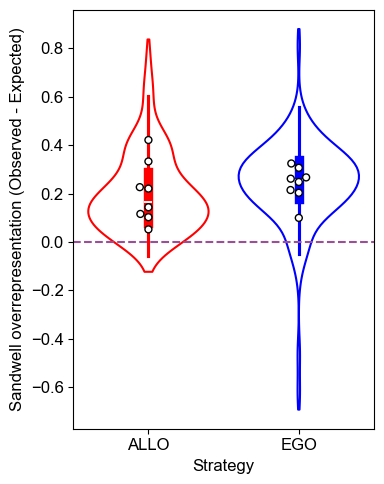

In [24]:

data_grouped=df.groupby(['subject','strategy'])['sandwell_overrepresentation'].mean().reset_index()

palette_egoallo = {
    "ALLO": "red",
    "EGO": "blue"
}

palette_white = {
    "ALLO": "white",
    "EGO": "white"
}

plt.figure(figsize=(4,5))

sns.violinplot(
    data=df,
    hue="strategy",
    y="sandwell_overrepresentation",
    inner='boxplot',
    cut=True,
    x='strategy',
   # dodge=True,
    palette=palette_egoallo,
    fill=False,
    #split=True
)

plt.axhline(0, linestyle= '--', color='#9B4F96')

#-----------------------------


model = smf.mixedlm(
    "sandwell_overrepresentation ~ strategy + trial_stage",
    df,
    groups=df["subject"],
)

result = model.fit(reml=False)
print(result.summary())
#-----------------------------

sns.swarmplot(
    data=data_grouped,
    hue="strategy",
    y="sandwell_overrepresentation",
    x='strategy',
    #dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5
)

plt.ylabel('Sandwell overrepresentation (Observed - Expected)')
plt.xlabel('Strategy')

#plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs\Decoder', 
                         "SW overrepresentation ego allo from sam cho.svg"), dpi=300, bbox_inches="tight")

plt.show()


In [9]:
analysis_='\\for_animal_overrepresentation' 

df=pd.DataFrame()

for phase in ['\Phase1', '\Phase2']:
    folder_ = folder + phase + analysis_
    file= '\sandwell_overrepresentation_panel2_difference_all_sessions.csv'

    df_=pd.read_csv(folder_+file)

    df=pd.concat([df,df_]).reset_index(drop=True)

In [10]:
df

,phase,subject,session,strategy,location_class,observed_minus_expected
0,1,H2226,A28,ALLO,1,0.081268
1,1,H2226,A28,ALLO,2,-0.004206
2,1,H2226,A28,ALLO,3,0.004632
3,1,H2226,A28,ALLO,4,-0.028596
4,1,H2226,A28,ALLO,5,0.017311
...,...,...,...,...,...,...
699,2,H2231,A34,ALLO,3,-0.011360
700,2,H2231,A34,ALLO,4,0.053175
701,2,H2231,A34,ALLO,5,0.003910
702,2,H2231,A34,ALLO,6,0.025894


C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWa

                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: observed_minus_expected
No. Observations: 704     Method:             ML                     
No. Groups:       8       Scale:              0.0161                 
Min. group size:  49      Log-Likelihood:     454.5610               
Max. group size:  98      Converged:          Yes                    
Mean group size:  88.0                                               
-----------------------------------------------------------------------
                   Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
-----------------------------------------------------------------------
Intercept           0.000      0.007    0.065   0.948   -0.013    0.014
strategy[T.EGO]    -0.000      0.010   -0.000   1.000   -0.019    0.019
Group Var           0.000                                              



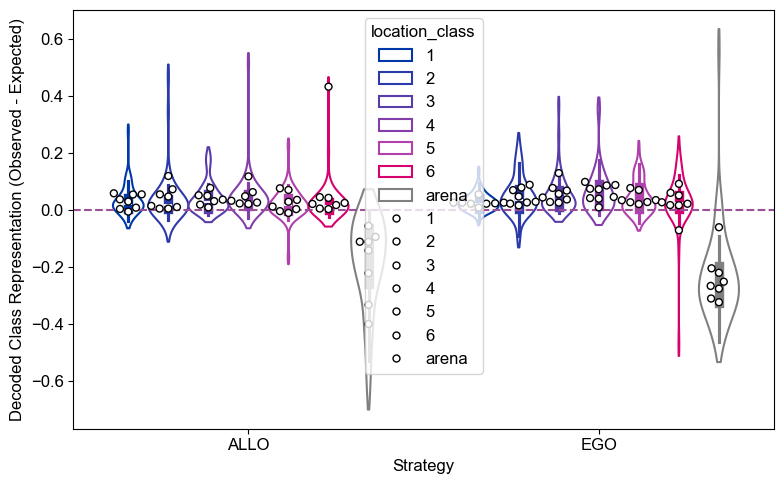

In [11]:

data_grouped=df.groupby(['subject','strategy', 'location_class'])['observed_minus_expected'].mean().reset_index()

palette_sw = {
    '1':'#0038A8','2':'#2C3AA9','3':'#583CAA','4':'#843EAB','5':'#B040AC','6':'#D60270','arena':'gray'
}




palette_white = {
    '1':'w','2':'w','3':'w','4':'w','5':'w','6':'w','arena':'w'
}

plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    hue="location_class",
    y="observed_minus_expected",
    inner='boxplot',
    cut=True,
    x='strategy',
    hue_order=['1','2','3','4','5','6','arena'],
   # dodge=True,
    palette=palette_sw,
    fill=False,
    #split=True
)

plt.axhline(0, linestyle= '--', color='#9B4F96')

#-----------------------------


model = smf.mixedlm(
    "observed_minus_expected ~ strategy ",
    df,
    groups=df["subject"],
)

result = model.fit(reml=False)
print(result.summary())
#-----------------------------

sns.swarmplot(
    data=data_grouped,
    hue="location_class",
    y="observed_minus_expected",
    x='strategy',
    dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5,
    hue_order=['1','2','3','4','5','6','arena'],
)

plt.ylabel('Decoded Class Representation (Observed - Expected)')
plt.xlabel('Strategy')

#plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs\Decoder', 
                         "SW obsaerved minus expected.svg"), dpi=300, bbox_inches="tight")

plt.show()


In [12]:
analysis_='\\for_animal_overrepresentation' 

df=pd.DataFrame()

for phase in ['\Phase1', '\Phase2']:
    folder_ = folder + phase + analysis_
    file= '\sandwell_overrepresentation_panel3_grouped_all_sessions.csv'

    df_=pd.read_csv(folder_+file)

    df=pd.concat([df,df_]).reset_index(drop=True)
df

,phase,subject,session,strategy,location_group,observed_minus_expected
0,1,H2226,A28,ALLO,Arena,-0.062804
1,1,H2226,A28,ALLO,Sandwells,0.062804
2,1,H2226,A29,ALLO,Arena,-0.187538
3,1,H2226,A29,ALLO,Sandwells,0.187538
4,1,H2226,A30,ALLO,Arena,-0.057624
...,...,...,...,...,...,...
213,2,H2231,A32,ALLO,Sandwells,0.094486
214,2,H2231,A33,ALLO,Arena,-0.172834
215,2,H2231,A33,ALLO,Sandwells,0.172834
216,2,H2231,A34,ALLO,Arena,-0.095437


C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\fr87_\anaconda3\Lib\site-pack

                       Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     observed_minus_expected
No. Observations:       218         Method:                 ML                     
No. Groups:             8           Scale:                  0.0256                 
Min. group size:        26          Log-Likelihood:         inf                    
Max. group size:        28          Converged:              Yes                    
Mean group size:        27.2                                                       
-----------------------------------------------------------------------------------
                            Coef.   Std.Err.    z    P>|z|    [0.025       0.975]  
-----------------------------------------------------------------------------------
Intercept                    0.000 632471.313  0.000 1.000 -1239620.995 1239620.995
strategy[T.EGO]             -0.000      0.022 -0.000 1.000       -0.043       0.043
location_group[

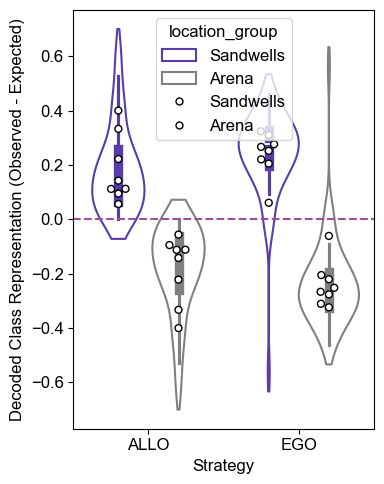

         Contrast      A          B  Paired  Parametric          T    dof  \
0  location_group  Arena  Sandwells   False        True -19.470366  216.0   

  alternative         p-unc       BF10    hedges  
0   two-sided  1.980046e-49  5.884e+45 -2.628231  


C:\Users\fr87_\anaconda3\Lib\site-packages\pingouin\pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


In [13]:

data_grouped=df.groupby(['subject','strategy', 'location_group'])['observed_minus_expected'].mean().reset_index()

palette_sw = {
'Sandwells':'#583CAA','Arena':'gray'
}


palette_white = {
'Sandwells':'w','Arena':'w'}

plt.figure(figsize=(4,5))

sns.violinplot(
    data=df,
    hue="location_group",
    y="observed_minus_expected",
    inner='boxplot',
    cut=True,
    x='strategy',
    hue_order=['Sandwells','Arena'],
   # dodge=True,
    palette=palette_sw,
    fill=False,
    #split=True
)

plt.axhline(0, linestyle= '--', color='#9B4F96')

#-----------------------------


model = smf.mixedlm(
    "observed_minus_expected ~ strategy + location_group",
    df,
    groups=df["subject"],
)

result = model.fit(reml=False)
print(result.summary())
#-----------------------------

sns.swarmplot(
    data=data_grouped,
    hue="location_group",
    y="observed_minus_expected",
    x='strategy',
    dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5,
    hue_order=['Sandwells','Arena'],
)


plt.ylabel('Decoded Class Representation (Observed - Expected)')
plt.xlabel('Strategy')
#plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs\Decoder', 
                         "SW obsaerved minus expected grouped.svg"), dpi=300, bbox_inches="tight")

plt.show()

import pingouin as pg

# One-way ANOVA
aov = pg.anova(data=df, dv='observed_minus_expected', between='location_group')

# Post-hoc pairwise comparisons
posthoc = pg.pairwise_ttests(
    data=df,
    dv='observed_minus_expected',
    between='location_group',
    padjust='bonf'
)

print(posthoc)


In [14]:
analysis_='\\for_animal_overrepresentation' 

df=pd.DataFrame()

for phase in ['\Phase1', '\Phase2']:
    folder_ = folder + phase + analysis_
    file= '\sandwell_overrepresentation_panel1_perclass_all_sessions.csv'

    df_=pd.read_csv(folder_+file)

    df=pd.concat([df,df_]).reset_index(drop=True)
df

,phase,subject,session,strategy,location_class,is_rewarded_well,training_frequency,expected_frequency,class_accuracy,testing_prediction
0,1,H2226,A28,ALLO,1,False,0.007431,0.009498,1.000000,0.090766
1,1,H2226,A28,ALLO,2,False,0.020842,0.026415,0.991643,0.022210
2,1,H2226,A28,ALLO,3,False,0.007605,0.009720,1.000000,0.014353
3,1,H2226,A28,ALLO,4,False,0.032163,0.037545,0.913357,0.008949
4,1,H2226,A28,ALLO,5,False,0.022874,0.029087,0.994924,0.046398
...,...,...,...,...,...,...,...,...,...,...
699,2,H2231,A34,ALLO,3,False,0.007925,0.013926,1.000000,0.002566
700,2,H2231,A34,ALLO,4,False,0.001648,0.002897,1.000000,0.056072
701,2,H2231,A34,ALLO,5,False,0.014266,0.025067,1.000000,0.028977
702,2,H2231,A34,ALLO,6,False,0.012744,0.021947,0.980100,0.047842


C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


               Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   class_accuracy
No. Observations:    595       Method:               ML            
No. Groups:          8         Scale:                0.0257        
Min. group size:     35        Log-Likelihood:       233.3962      
Max. group size:     84        Converged:            Yes           
Mean group size:     74.4                                          
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                 0.907    0.028 32.095 0.000  0.852  0.963
strategy[T.EGO]          -0.019    0.013 -1.403 0.161 -0.045  0.007
is_rewarded_well[T.True] -0.012    0.017 -0.713 0.476 -0.046  0.022
Group Var                 0.006    0.019                           



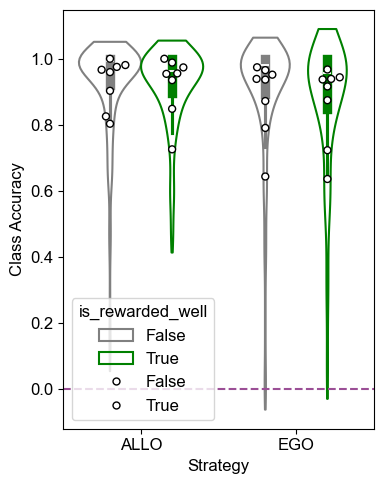

In [15]:
df=df[df['location_class']!='arena']

data_grouped=df.groupby(['subject','strategy', 'is_rewarded_well'])[['class_accuracy', 'testing_prediction']].mean().reset_index()

palette_sw = {
True:'green',False:'gray'
}


palette_white = {
True:'w',False:'w'}

plt.figure(figsize=(4,5))

sns.violinplot(
    data=df,
    hue="is_rewarded_well",
    y="class_accuracy",
    inner='boxplot',
    cut=True,
    x='strategy',
    hue_order=[False, True],
   # dodge=True,
    palette=palette_sw,
    fill=False,
    #split=True
)

plt.axhline(0, linestyle= '--', color='#9B4F96')

#-----------------------------


model = smf.mixedlm(
    "class_accuracy ~ strategy + is_rewarded_well",
    df,
    groups=df["subject"],
)

result = model.fit(reml=False)
print(result.summary())
#-----------------------------

sns.swarmplot(
    data=data_grouped,
    hue="is_rewarded_well",
    y="class_accuracy",
    x='strategy',
    dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5,
    hue_order=[False, True],
)


plt.ylabel('Class Accuracy')
plt.xlabel('Strategy')
#plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs\Decoder', 
                         "SW accuracy correct vs incorrect.svg"), dpi=300, bbox_inches="tight")
#
plt.show()






               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  testing_prediction
No. Observations:  595      Method:              ML                
No. Groups:        8        Scale:               0.0044            
Min. group size:   35       Log-Likelihood:      763.7969          
Max. group size:   84       Converged:           Yes               
Mean group size:   74.4                                            
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                 0.060    0.007  8.726 0.000  0.046  0.073
strategy[T.EGO]           0.010    0.005  1.820 0.069 -0.001  0.021
is_rewarded_well[T.True] -0.012    0.007 -1.703 0.088 -0.026  0.002
Group Var                 0.000    0.002                           



C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


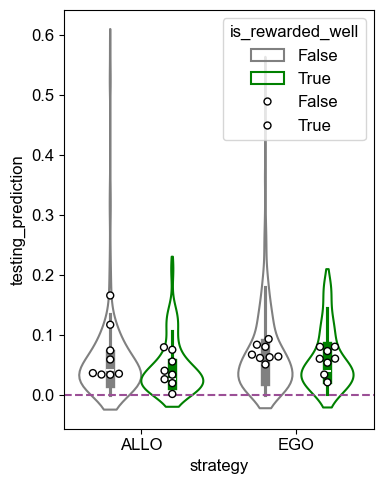

In [16]:
df=df[df['location_class']!='arena']

data_grouped=df.groupby(['subject','strategy', 'is_rewarded_well'])[['class_accuracy', 'testing_prediction']].mean().reset_index()

palette_sw = {
True:'green',False:'gray'
}


palette_white = {
True:'w',False:'w'}

plt.figure(figsize=(4,5))

sns.violinplot(
    data=df,
    hue="is_rewarded_well",
    y="testing_prediction",
    inner='boxplot',
    cut=True,
    x='strategy',
    hue_order=[False, True],
   # dodge=True,
    palette=palette_sw,
    fill=False,
    #split=True
)

plt.axhline(0, linestyle= '--', color='#9B4F96')

#-----------------------------


model = smf.mixedlm(
    "testing_prediction ~ strategy + is_rewarded_well",
    df,
    groups=df["subject"],
)

result = model.fit(reml=False)
print(result.summary())
#-----------------------------

sns.swarmplot(
    data=data_grouped,
    hue="is_rewarded_well",
    y="testing_prediction",
    x='strategy',
    dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5,
    hue_order=[False, True],
)



#plt.yscale("log")
plt.tight_layout()
#plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs\Decoder', 
#                         "SW accuracy correct vs incorrect.svg"), dpi=300, bbox_inches="tight")
#
plt.show()






C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: observed_minus_expected
No. Observations: 595     Method:             ML                     
No. Groups:       8       Scale:              0.0008                 
Min. group size:  35      Log-Likelihood:     1279.3178              
Max. group size:  84      Converged:          Yes                    
Mean group size:  74.4                                               
---------------------------------------------------------------------
                             Coef. Std.Err.   z   P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                    0.023    0.004 5.382 0.000  0.015  0.031
strategy[T.EGO]              0.001    0.002 0.582 0.561 -0.003  0.006
is_rewarded_well[T.True]     0.005    0.003 1.546 0.122 -0.001  0.011
Group Var                    0.000    0.003                          



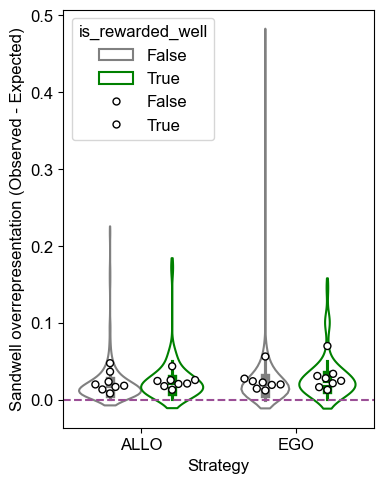

In [17]:
analysis_='\\for_animal_overrepresentation' 

df=pd.DataFrame()

for phase in ['\Phase1', '\Phase2']:
    folder_ = folder + phase + analysis_
    file= '\sandwell_overrepresentation_panel1_perclass_all_sessions.csv'

    df_=pd.read_csv(folder_+file)

    df=pd.concat([df,df_]).reset_index(drop=True)


df=df[df['location_class']!='arena']
df['observed_minus_expected']=df['testing_prediction']=df['expected_frequency']

data_grouped=df.groupby(['subject','strategy', 'is_rewarded_well'])['observed_minus_expected'].mean().reset_index()

palette_sw = {
True:'green',False:'gray'
}


palette_white = {
True:'w',False:'w'}

plt.figure(figsize=(4,5))

sns.violinplot(
    data=df,
    hue="is_rewarded_well",
    y="observed_minus_expected",
    inner='boxplot',
    cut=True,
    x='strategy',
    hue_order=[False, True],
   # dodge=True,
    palette=palette_sw,
    fill=False,
    #split=True
)

plt.axhline(0, linestyle= '--', color='#9B4F96')

#-----------------------------


model = smf.mixedlm(
    "observed_minus_expected ~ strategy + is_rewarded_well",
    df,
    groups=df["subject"],
)

result = model.fit(reml=False)
print(result.summary())
#-----------------------------

sns.swarmplot(
    data=data_grouped,
    hue="is_rewarded_well",
    y="observed_minus_expected",
    x='strategy',
    dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5,
    hue_order=[False, True],
)


plt.ylabel('Sandwell overrepresentation (Observed - Expected)')
plt.xlabel('Strategy')

#plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs\Decoder', 
                         "obs - expected correct vs incorrect.svg"), dpi=300, bbox_inches="tight")
#
plt.show()






In [25]:
analysis_='\\sandwell_uniformity_EGO_vs_ALLO' 

df=pd.DataFrame()

for phase in ['\Phase1', '\Phase2']:
    folder_ = folder + phase + analysis_
    file= '\ego_vs_allo_sandwell_uniformity.csv'

    df_=pd.read_csv(folder_+file)

    df=pd.concat([df,df_]).reset_index(drop=True)
df

,strategy,phase,subject,session,entropy,max_minus_second_max,n_sandwells
0,EGO,1,H2222,E28,1.403886,0.277995,6
1,EGO,1,H2222,E29,0.470769,0.714876,6
2,EGO,1,H2222,E30,0.665106,0.582570,4
3,EGO,1,H2222,E31,0.000000,0.000000,1
4,EGO,1,H2222,E32,0.373409,0.753441,2
...,...,...,...,...,...,...,...
102,ALLO,2,H2231,A30,1.580695,0.222454,6
103,ALLO,2,H2231,A31,1.621806,0.014175,6
104,ALLO,2,H2231,A32,1.755811,0.012223,6
105,ALLO,2,H2231,A33,1.612101,0.191646,6


              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: max_minus_second_max
No. Observations: 107     Method:             ML                  
No. Groups:       8       Scale:              0.0404              
Min. group size:  12      Log-Likelihood:     14.1853             
Max. group size:  14      Converged:          Yes                 
Mean group size:  13.4                                            
--------------------------------------------------------------------
                  Coef.   Std.Err.     z     P>|z|   [0.025   0.975]
--------------------------------------------------------------------
Intercept         0.190      0.044   4.284   0.000    0.103    0.278
strategy[T.EGO]   0.037      0.039   0.956   0.339   -0.039    0.114
Group Var         0.009      0.033                                  



C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


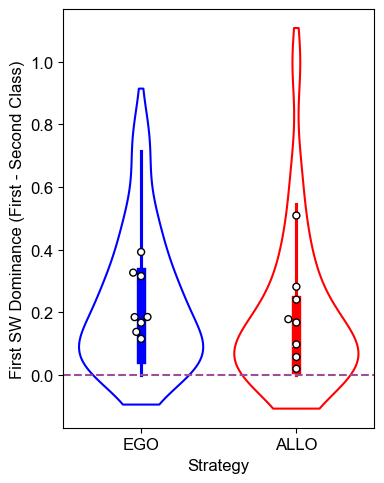

In [26]:

data_grouped=df.groupby(['subject','strategy'])[['max_minus_second_max','n_sandwells']].mean().reset_index()

palette_egoallo = {
    "ALLO": "red",
    "EGO": "blue"
}

palette_white = {
    "ALLO": "white",
    "EGO": "white"
}

plt.figure(figsize=(4,5))

sns.violinplot(
    data=df,
    hue="strategy",
    y="max_minus_second_max",
    inner='boxplot',
    cut=True,
    x='strategy',
    hue_order=['EGO', 'ALLO'],
   # dodge=True,
    palette=palette_egoallo,
    fill=False,
    #split=True
)

plt.axhline(0, linestyle= '--', color='#9B4F96')

#-----------------------------


model = smf.mixedlm(
    "max_minus_second_max ~ strategy ",
    df,
    groups=df["subject"],
)

result = model.fit(reml=False)
print(result.summary())
#-----------------------------

sns.swarmplot(
    data=data_grouped,
    hue="strategy",
    y="max_minus_second_max",
    x='strategy',
    #dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5,
    hue_order=['EGO', 'ALLO'],
)

plt.ylabel('First SW Dominance (First - Second Class)')
plt.xlabel('Strategy')

#plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs\Decoder', 
                         "SW prediction 1-2.svg"), dpi=300, bbox_inches="tight")
#
plt.show()






          Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  entropy 
No. Observations:   107      Method:              ML      
No. Groups:         8        Scale:               0.0655  
Min. group size:    12       Log-Likelihood:      -19.1157
Max. group size:    14       Converged:           Yes     
Mean group size:    13.4                                  
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        1.369    0.130 10.539 0.000  1.114  1.623
strategy[T.EGO] -0.011    0.050 -0.221 0.825 -0.108  0.086
Group Var        0.125    0.264                           



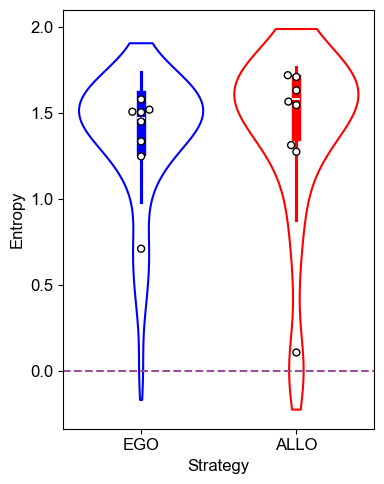

In [27]:

data_grouped=df.groupby(['subject','strategy'])[['max_minus_second_max','entropy']].mean().reset_index()

palette_egoallo = {
    "ALLO": "red",
    "EGO": "blue"
}

palette_white = {
    "ALLO": "white",
    "EGO": "white"
}

plt.figure(figsize=(4,5))

sns.violinplot(
    data=df,
    hue="strategy",
    y="entropy",
    inner='boxplot',
    cut=True,
    x='strategy',
    hue_order=['EGO', 'ALLO'],
   # dodge=True,
    palette=palette_egoallo,
    fill=False,
    #split=True
)

plt.axhline(0, linestyle= '--', color='#9B4F96')

#-----------------------------


model = smf.mixedlm(
    "entropy ~ strategy ",
    df,
    groups=df["subject"],
)

result = model.fit(reml=False)
print(result.summary())
#-----------------------------

sns.swarmplot(
    data=data_grouped,
    hue="strategy",
    y="entropy",
    x='strategy',
    #dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5,
    hue_order=['EGO', 'ALLO'],
)


plt.ylabel('Entropy')
plt.xlabel('Strategy')
#plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs\Decoder', 
                         "entropy.svg"), dpi=300, bbox_inches="tight")
#
plt.show()




